# **A/B Testing & Conversion Optimization**
---

## **TABLE OF CONTENTS**
1. [BUSINESS PROBLEM](#1.-BUSINESS-PROBLEM)
2. [POWER ANALYSIS](#POWER-ANALYSIS-(Pre-Experiment-Validation))
3. [DATA GENERATION](#3.-DATA-GENERATION)
4. [SQL ANALYSIS](#4.-SQL-ANALYSIS)
5. [DATA VALIDATION](#5.-DATA-VALIDATION)
6. [STATISTICAL TESTING](#6.-STATISTICAL-TESTING)
7. [ADVANCED ANALYSIS](#7.-ADVANCED-ANALYSIS)
8. [BUSINESS IMPACT & FINAL RECOMMENDATION](#8.-BUSINESS-IMPACT--FINAL-RECOMMENDATION)

## **BUSINESS PROBLEM**
---

### ***Objective***
Evaluate whether a redesigned digital credit card onboarding experience improves user conversion performance by increasing application completion rates.

The primary objective is to determine whether the redesigned experience produces a **statistically and practically meaningful improvement** in conversions relative to the existing onboarding flow.

### ***Experiment***
The experiment compares:
- **Variant A** — Existing onboarding experience (**control**)
- **Variant B** — Redesigned onboarding experience (**treatment**).

The analysis measures the impact of the redesign on user application completion behavior.

### ***Metrics***
#### *Primary Metric*
The primary success metric is the proportion of users who successfully complete the application process.
$$
\text{Conversion Rate} =
\frac{\text{Completed Applications}}
{\text{Total Users}}
$$

#### *Secondary Metrics*
Secondary metrics help evaluate how users progress through the onboarding journey.

* Funnel progression by stage
* Drop-off rate at each funnel step

These metrics provide additional insight into where users abandon the application flow and where the redesigned experience may improve completion behavior.

#### *Guardrail Metrics*
Guardrail metrics ensure that improvements in the primary metric do not come at the expense of user experience quality across key segments.

* No significant decline in mobile conversion performance
* No increase in abandonment during onboarding completion stages
**
These checks help ensure that observed improvements remain broadly beneficial across users and do not introduce unintended negative effects.

### ***Hypothesis***
The experiment evaluates whether the redesigned onboarding experience improves conversion performance relative to the existing design.

**Null Hypothesis (H₀):** Conversion rate of Variant B ≤ Conversion rate of Variant A

**Alternative Hypothesis (H₁):** Conversion rate of Variant B > Conversion rate of Variant A

### ***Experiment Assumptions***
The validity of the experiment relies on several standard A/B testing assumptions:
- Users are randomly assigned to experimental variants
- Observations are independent across users
- External conditions (traffic mix, timing, campaigns, and user acquisition patterns) remain reasonably stable throughout the experiment
- Conversion outcomes are measured consistently across both variants

**Unit of Analysis:** Each observation represents a unique user, and conversion is measured at the individual user level.

**Sample Size Consideration:** A sufficiently large sample size is required to ensure adequate statistical power, stable conversion estimates, and and reliable inference regarding treatment effects.

## **POWER ANALYSIS (Pre-Experiment Validation)**
---

To mirror realistic experimentation practice, an a priori power analysis is performed before simulating the experiment. This estimates the minimum required sample size needed to reliably detect a meaningful uplift in conversion performance.

### ***Assumptions:***
* *Expected baseline conversion rate (Variant A):* ***12%***
* *Expected conversion rate (Variant B):* ***15%***
* *Minimum detectable effect:* 3 percentage point absolute uplift
* *Significance level ($\alpha $):* ***0.05***
* *Desired statistical power:* ***0.8***

This ensures that if a true treatment effect exists, the experiment has an 80% probability of detecting it as statistically significant.

#### ***Sample Size Calculation***

In [1]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil

# Baseline and expected treatment conversion rates
p1 = 0.12
p2 = 0.15

# Compute standardized effect size
effect_size = proportion_effectsize(p1, p2)

# Initialize power analysis
analysis = NormalIndPower()

# Solve for required sample size
sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

# Round up to nearest whole number
sample_size = ceil(sample_size)

print("Required sample size per group:", sample_size)

Required sample size per group: 2031


The power analysis indicates that approximately **2,031 users per variant** are required to reliably detect a **3 percentage point absolute uplift** at the specified significance level and statistical power.

This helps reduce the likelihood of Type II error and ensures that the experiment is sufficiently powered to detect practically meaningful treatment effects.

## **DATA GENERATION**
---

To evaluate the experiment, we simulate a realistic user-level dataset that reflects common patterns observed in digital onboarding and conversion funnels.

Rather than using purely random outcomes, conversion probability is modeled as a function of user characteristics and treatment assignment to create a more realistic experimentation environment.

### ***Conversion Logic***
Conversion probability is defined using several underlying behavioral and user-level drivers.

#### *Expected Base Conversion Rate*
All users begin with a baseline conversion probability of approximately **12%**.

#### *Modeled Effects*:
- **Variant Effect:** Users assigned to **Variant B** receive a positive treatment effect corresponding to an approximate **3 percentage point uplift** in conversion probability. This simulates the impact of an improved onboarding experience.

- **Device Effect:** Mobile users receive a small negative adjustment to conversion probability. This reflects the common observation that mobile onboarding experiences may involve smaller screens, reduced input efficiency or higher interaction friction.

- **Customer Status Effect:** Returning customers receive a positive adjustment to conversion probability. This reflects greater familiarity with the product, higher trust, and increased purchase intent.

### ***Conceptual Model***
```python
conversion_prob = base
                + variant_effect
                + device_effect
                + customer_effect
```
The final probability is clipped to remain within valid probability bounds between 0 and 1.

### ***Data Schema***
The simulated dataset is organized into multiple relational tables to resemble a simplified analytical pipeline.

#### `users` Table
| Column              | Description                     |
| ------------------- | ------------------------------- |
| `user_id`           | Unique user identifier          |
| `device`            | Device type (mobile or desktop) |
| `age_group`         | User demographic segment        |
| `previous_customer` | Returning customer indicator    |

#### `experiment` Table
| Column      | Description               |
| ----------- | ------------------------- |
| `user_id`   | Unique user identifier    |
| `variant`   | Experimental assignment   |
| `converted` | Binary conversion outcome |

#### `behavior` Table
| Column         | Description                   |
| -------------- | ----------------------------- |
| `user_id`      | Unique user identifier        |
| `session_time` | Simulated session duration    |
| `pages_viewed` | Simulated engagement activity |

#### `events` Table
| Column       | Description              |
| ------------ | ------------------------ |
| `user_id`    | Unique user identifier   |
| `event`      | Funnel stage             |
| `step_order` | Funnel sequence position |

### ***Data Generation Process***

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)   # Reproducibility
n = 30000            # Number of users

# Step 1: Generate User Attributes
users = pd.DataFrame({
    "user_id": range(n),
    "device": np.random.choice(["mobile", "desktop"], p=[0.7, 0.3], size=n),
    "age_group": np.random.choice(["18-25","26-35","36-50"], size=n),
    "previous_customer": np.random.choice([0,1], p=[0.8,0.2], size=n),
    "session_time": np.random.gamma(shape=2, scale=60, size=n),
    "pages_viewed": np.random.poisson(lam=5, size=n)
})

# Step 2: Assign Variants (Randomization)
users["variant"] = np.random.choice(["A", "B"], size=n)

# Step 3: Simulate Conversion
def compute_conversion(row):

    # Baseline conversion probability
    prob = 0.12

    # Treatment effect
    if row["variant"] == "B":
        prob += 0.03

    # Device effect
    if row["device"] == "mobile":
        prob -= 0.02

    # Returning customer effect
    if row["previous_customer"] == 1:
        prob += 0.02

    # Ensure valid probability bounds
    prob = max(min(prob, 0.90), 0.01)

    return np.random.binomial(1, prob)

# Generate conversion outcomes
users["converted"] = users.apply(compute_conversion, axis=1)

# Preview dataset
print(users.head())
print()
print(users.info())

   user_id   device age_group  previous_customer  session_time  pages_viewed  \
0        0   mobile     18-25                  0     28.717787             5   
1        1  desktop     36-50                  0     63.097671             5   
2        2  desktop     26-35                  0     78.653188             7   
3        3   mobile     18-25                  0     92.862490             8   
4        4   mobile     26-35                  0    109.383135             3   

  variant  converted  
0       A          0  
1       B          0  
2       A          0  
3       B          1  
4       B          0  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            30000 non-null  int64  
 1   device             30000 non-null  object 
 2   age_group          30000 non-null  object 
 3   previous_customer  30000 no

The generated dataset contains user-level behavioral, demographic, and experimental features required for downstream analysis.

In [3]:
# Step 4: Generate Funnel Events
events = []

for _, row in users.iterrows():

    # Landing page always reached
    events.append([row["user_id"], "landing", 1])

    # Start stage
    if np.random.rand() < 0.70:

        events.append([row["user_id"], "start", 2])

        # Form stage
        if np.random.rand() < 0.72:

            events.append([row["user_id"], "form", 3])

            # Submit stage depends on conversion outcome
            if row["converted"] == 1:

                events.append([row["user_id"], "submit", 4])

# Create events dataframe
events = pd.DataFrame(events, columns=["user_id", "event", "step_order"])
events

,user_id,event,step_order
0,0,landing,1
1,0,start,2
2,0,form,3
3,1,landing,1
4,2,landing,1
...,...,...,...
67954,29998,landing,1
67955,29998,start,2
67956,29998,form,3
67957,29998,submit,4


### ***Sanity Checks***

#### *Variant Allocation*

In [4]:
# User allocation by variant
users["variant"].value_counts()

variant
B    15031
A    14969
Name: count, dtype: int64

The allocation between variants is nearly perfectly balanced, supporting the validity of the randomization process.

#### *Conversion Rate by Variant*

In [5]:
# Conversion rate by variant
users.groupby("variant")["converted"].mean()

variant
A    0.107622
B    0.138447
Name: converted, dtype: float64

* Variant B achieves a conversion rate of approximately **13.8%**, compared to **10.8%** for Variant A.
* The simulated treatment effect produces an uplift of roughly **3 percentage points**, aligning with the experimental design assumptions.
* User allocation across variants is balanced and substantially exceeds the minimum required sample size identified in the power analysis.

This ensures that the simulated experiment is sufficiently powered to support reliable downstream statistical analysis.

### ***Conclusion:***
The simulated dataset reflects realistic experimentation structure and user-level variability while maintaining controlled treatment effects and balanced randomization.

The generated data provides a strong foundation for statistical testing, segmentation analysis, funnel evaluation, and multivariate modeling of conversion behavior.

## **SQL ANALYSIS**
---

### ***Data Modeling***
The dataset is organized into multiple relational tables to mimic a simplified production-style analytical schema:
* `users` → user attributes and customer information
* `experiment` → experiment assignment and conversion outcomes
* `behavior` → aggregated session-level engagement metrics
* `events` → event-level funnel progression data
This structure enables modular querying, relational joins, reusable analytical views, and scalable downstream analysis.

### ***Load Data into SQL***

In [6]:
import sqlite3

# Create SQLite database connection
conn = sqlite3.connect("ab_test.db")

# User table
users[["user_id", "device", "previous_customer"]].to_sql(
    "users", conn, if_exists="replace", index=False
)

# Experiment table
users[["user_id", "variant", "converted"]].to_sql(
    "experiment", conn, if_exists="replace", index=False
)

# Behavior table
users[["user_id", "session_time", "pages_viewed"]].to_sql(
    "behavior", conn, if_exists="replace", index=False
)

# Events table
events.to_sql("events", conn, if_exists="replace", index=False)

67959

### ***Overall Conversion (A vs B)***
To evaluate overall experiment performance, we compare conversion rates between Variant A and Variant B.

In [8]:
# Conversion Rate by Variant
query_conversion = """
SELECT 
    variant,
    COUNT(*) AS users,                         -- total users in each variant
    SUM(converted) AS conversions,             -- total conversions
    ROUND(SUM(converted)*1.0 / COUNT(*), 4) AS conversion_rate
FROM experiment
GROUP BY variant;
"""

# Load query results into a DataFrame
df_conversion = pd.read_sql(query_conversion, conn)
df_conversion

,variant,users,conversions,conversion_rate
0,A,14969,1611,0.1076
1,B,15031,2081,0.1384


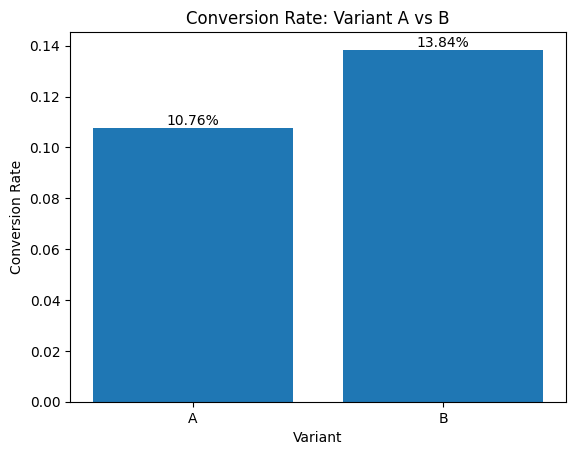

In [9]:
import matplotlib.pyplot as plt

# Create bar chart for conversion rates
plt.figure()
bars = plt.bar(df_conversion["variant"], df_conversion["conversion_rate"])


# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2%}",  
        ha='center',
        va='bottom'
    )

plt.xlabel("Variant")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate: Variant A vs B")
plt.show()

Variant B achieves a conversion rate of approximately **13.8%**, compared to **10.8%** for Variant A.

This represents an uplift of roughly **3 percentage points**, suggesting that the redesigned onboarding experience may reduce friction and improve conversion efficiency.

### ***Conversion by Device (Segmentation)***
To evaluate whether experiment performance varies across user segments, we compare conversion rates by device type.

In [10]:
# Conversion rate by device and variant
query_device = """
SELECT 
    u.device,
    e.variant,
    COUNT(*) AS users,
    ROUND(SUM(e.converted)*1.0 / COUNT(*), 4) AS conversion_rate
FROM experiment e
JOIN users u 
ON e.user_id = u.user_id
GROUP BY u.device, e.variant;
"""

# Load segmented conversion data
df_device = pd.read_sql(query_device, conn)
df_device

,device,variant,users,conversion_rate
0,desktop,A,4365,0.1173
1,desktop,B,4548,0.1535
2,mobile,A,10604,0.1036
3,mobile,B,10483,0.1319


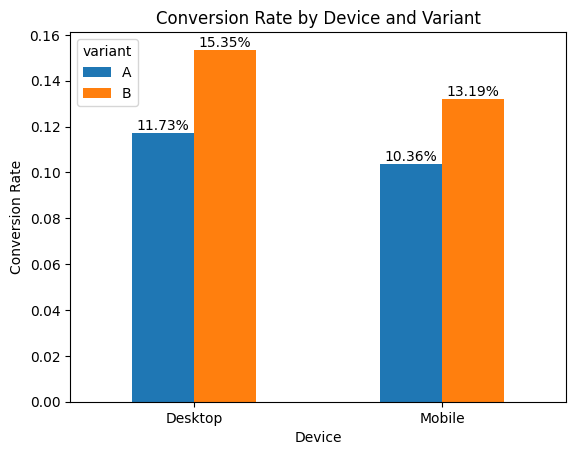

In [11]:
# Pivot data for plotting
pivot_device = df_device.pivot(index="device", columns="variant", values="conversion_rate")

# Rename index labels
pivot_device.index = ["Desktop", "Mobile"]

# Create grouped bar chart
ax = pivot_device.plot(kind="bar")

# Add percentage labels on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2%}",
            ha='center',
            va='bottom'
        )

plt.xlabel("Device")
plt.xticks(rotation=0)
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Device and Variant")

plt.show()

- Variant B consistently outperforms Variant A across both desktop and mobile devices.
- Desktop users exhibit higher overall conversion rates than mobile users.
- Mobile users show lower conversion performance overall, potentially reflecting differences in user experience across devices.

The consistent uplift across segments suggests that the treatment effect generalizes across major device categories.

### ***Combined Analytical View***
To simplify downstream analysis, we create a consolidated SQL view that combines:
- user attributes,
- experiment assignment,
- and behavioral metrics.
This eliminates the need for repeated joins during segmentation, modeling, and funnel analysis.

In [12]:
# Drop existing view if present
conn.execute("DROP VIEW IF EXISTS full_data")

# Create consolidated analytical view
conn.execute("""
CREATE VIEW full_data AS
SELECT 
    u.user_id,
    u.device,
    u.previous_customer,
    e.variant,
    e.converted,
    b.session_time,
    b.pages_viewed
FROM users u
JOIN experiment e
    ON u.user_id = e.user_id
JOIN behavior b
    ON u.user_id = b.user_id;
""")

# Load the consolidated dataset
df_full_data = pd.read_sql("SELECT * FROM full_data", conn)

# Preview first few rows
df_full_data.head()

,user_id,device,previous_customer,variant,converted,session_time,pages_viewed
0,0,mobile,0,A,0,28.717787,5
1,1,desktop,0,B,0,63.097671,5
2,2,desktop,0,A,0,78.653188,7
3,3,mobile,0,B,1,92.862490,8
4,4,mobile,0,B,0,109.383135,3


### ***Funnel Analysis (User Journey)***
To better understand onboarding progression, we analyze user movement through sequential event-level funnel stages.

In [13]:
# Funnel summary
query_funnel_summary = """
SELECT 
    event AS step,
    COUNT(DISTINCT user_id) AS users,
    ROUND(COUNT(DISTINCT user_id) * 1.0 / (SELECT COUNT(DISTINCT user_id) 
          FROM events WHERE event = 'landing'), 4) AS conversion_rate
FROM events
GROUP BY event
ORDER BY 
    CASE event
        WHEN 'landing' THEN 1
        WHEN 'start' THEN 2
        WHEN 'form' THEN 3
        WHEN 'submit' THEN 4
    END;
"""

# Load funnel summary
df_funnel = pd.read_sql(query_funnel_summary, conn)
df_funnel

,step,users,conversion_rate
0,landing,30000,1.0000
1,start,20960,0.6987
2,form,15131,0.5044
3,submit,1868,0.0623


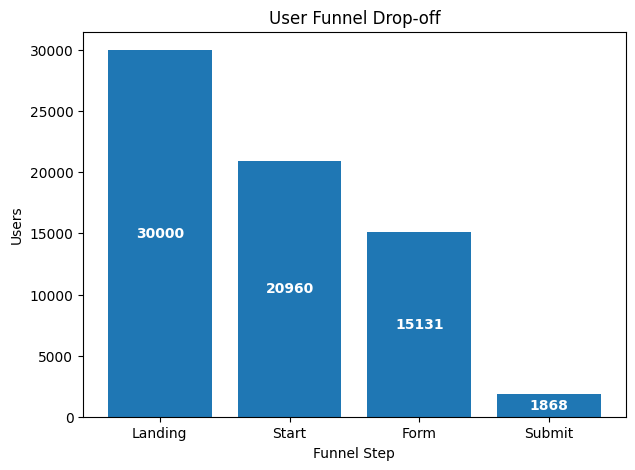

In [14]:
# Funnel drop-off visualization
plt.figure(figsize=(7, 5))

bars = plt.bar(df_funnel["step"], df_funnel["users"])

# Add labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height / 2,
        f"{int(height)}",
        ha='center',
        va='center',
        color='white',
        fontweight='bold'
    )

plt.xlabel("Funnel Step")
plt.ylabel("Users")
plt.title("User Funnel Drop-off")

plt.xticks(
    ticks=range(len(df_funnel["step"])),
    labels=["Landing", "Start", "Form", "Submit"]
)

plt.show()

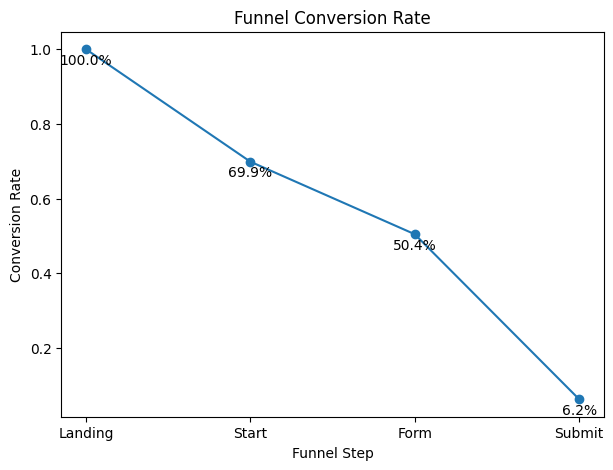

In [15]:
# Funnel conversion rate visualization
plt.figure(figsize=(7, 5))
plt.plot(df_funnel["step"], df_funnel["conversion_rate"], marker='o')

# Add labels
for x, y in zip(df_funnel["step"], df_funnel["conversion_rate"]):

    plt.text(x, y - 0.01, f"{y:.1%}", ha='center', va='top')

plt.xlabel("Funnel Step")
plt.ylabel("Conversion Rate")
plt.title("Funnel Conversion Rate")

plt.xticks(
    ticks=range(len(df_funnel["step"])),
    labels=["Landing", "Start", "Form", "Submit"]
)

plt.show()

- Approximately **70% of users** progress from the landing stage to the start stage.
- Conversion declines steadily throughout the funnel, indicating increasing friction deeper in the onboarding process.
- The largest drop-off occurs between the **form** and **submit** stages, where only a small proportion of users complete the final conversion step.

These results suggest that the primary conversion bottleneck occurs near the end of the onboarding journey.

### ***Funnel by Variant (A vs B)***
To identify where the treatment effect occurs within the user journey, we compare funnel progression separately for Variant A and Variant B.

In [16]:
# Funnel analysis by variant
query_funnel_variant = """
WITH base AS (
    -- Total users per experiment variant
    SELECT 
        variant,
        COUNT(DISTINCT user_id) AS total_users
    FROM experiment
    GROUP BY variant
)
SELECT 
    e.variant,
    ev.event AS step,
    -- Users reaching each funnel step
    COUNT(DISTINCT ev.user_id) AS users,
    -- Step conversion rate within each variant
    ROUND(COUNT(DISTINCT ev.user_id) * 1.0 / b.total_users, 4) AS conversion_rate
FROM events ev
JOIN experiment e ON ev.user_id = e.user_id
JOIN base b ON e.variant = b.variant
GROUP BY e.variant, ev.event
ORDER BY 
    e.variant,
    CASE ev.event
        WHEN 'landing' THEN 1
        WHEN 'start' THEN 2
        WHEN 'form' THEN 3
        WHEN 'submit' THEN 4
    END;
"""

# Load funnel summary
df_funnel_variant = pd.read_sql( query_funnel_variant,  conn)
df_funnel_variant

,variant,step,users,conversion_rate
0,A,landing,14969,1.0000
1,A,start,10463,0.6990
2,A,form,7550,0.5044
3,A,submit,812,0.0542
4,B,landing,15031,1.0000
5,B,start,10497,0.6984
6,B,form,7581,0.5044
7,B,submit,1056,0.0703


<Figure size 800x600 with 0 Axes>

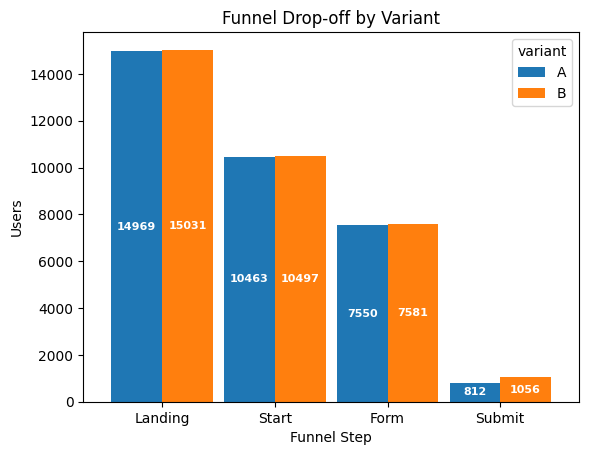

In [17]:
# Funnel User Drop-off by Variant Chart

# Step ordering
step_order = ["landing", "start", "form", "submit"]

df_funnel_variant["step"] = pd.Categorical(df_funnel_variant["step"], categories=step_order, ordered=True)

# Pivot table
pivot_users = df_funnel_variant.pivot(index="step", columns="variant", values="users")
pivot_rate = df_funnel_variant.pivot(index="step", columns="variant", values="conversion_rate")

plt.figure(figsize=(8, 6))

ax = pivot_users.plot(kind="bar", width=0.9)

# Add labels inside bars
for container in ax.containers:
    
    for bar in container:
        
        height = bar.get_height()
        
        ax.text(bar.get_x() + bar.get_width()/2, height / 2, f"{int(height)}",
                ha='center', va='center', color='white', fontweight='bold', fontsize=8)

plt.xlabel("Funnel Step")
plt.ylabel("Users")
plt.title("Funnel Drop-off by Variant")

plt.xticks(
    rotation=0,
    ticks=range(len(df_funnel["step"])),
    labels=["Landing", "Start", "Form", "Submit"]
)

plt.show()

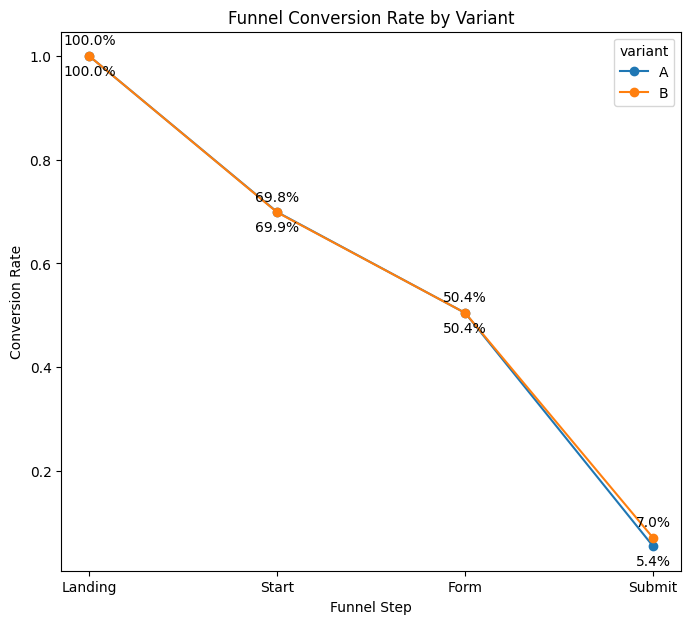

In [18]:
# Variant Funnel Conversion Rate
# Pivot conversion rates
pivot_rate = df_funnel_variant.pivot(index="step", columns="variant", values="conversion_rate")

# Plot conversion rates
ax = pivot_rate.plot(marker='o', figsize=(8, 7))

# Label offsets
offsets = {"A": -0.03, "B": 0.03}

# Add labels
ax = plt.gca()

for line in ax.lines:
    
    variant = line.get_label()
    
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    
    for x, y in zip(x_data, y_data):
        
        ax.text(x, y + offsets[variant], f"{y:.1%}", ha='center', va='center')

plt.xlabel("Funnel Step")
plt.ylabel("Conversion Rate")
plt.title("Funnel Conversion Rate by Variant")

plt.xticks(
    ticks=range(len(df_funnel["step"])),
    labels=["Landing", "Start", "Form", "Submit"]
)

plt.show()

- Variants A and B show nearly identical progression through the landing, start, and form stages.
- The largest divergence appears at the final **submit** stage, where Variant B achieves a noticeably higher completion rate.
- This suggests that the redesigned experience primarily improves the final conversion step rather than early-stage engagement.
- Since earlier-stage funnel behavior remains highly similar across variants, the treatment effect appears concentrated near the end of the onboarding journey.

## **DATA VALIDATION**
---

Before interpreting experimental results, it is essential to verify that the A/B test setup is reliable and free from major allocation issues.

Common risks in experimentation include:
* Unequal group sizes
* Allocation bias during randomization
* Imbalanced user distribution across segments
* Sample Ratio Mismatch (SRM)

If these issues are present, statistical conclusions may become unreliable regardless of significance levels.

### ***Group Size Validation***
To verify balanced allocation, we first compare the number of users assigned to each experimental variant.

In [19]:
# Check user distribution across variants
query_group_size = """
SELECT 
    variant AS "Variant",
    COUNT(*) AS "Users"
FROM experiment
GROUP BY variant;
"""

df_group_size = pd.read_sql(query_group_size, conn)
df_group_size

,Variant,Users
0,A,14969
1,B,15031


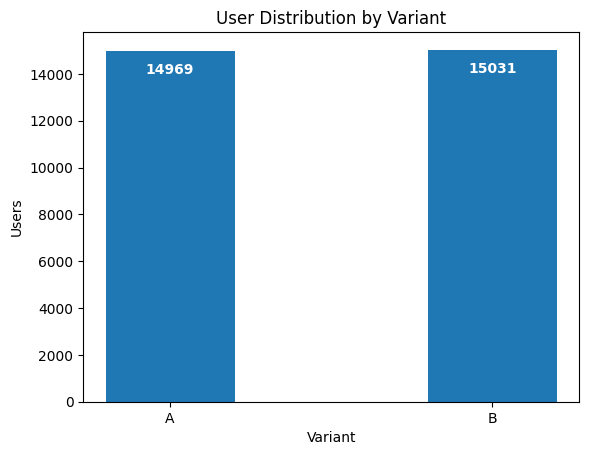

In [20]:
# Visualize group size balance
plt.figure()

bars = plt.bar(df_group_size["Variant"], df_group_size["Users"], width=0.4)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height - 500,
        f'{int(height)}',
        ha='center',
        va='top',
        color='white',
        fontweight='bold'
    )

plt.xlabel("Variant")
plt.ylabel("Users")
plt.title("User Distribution by Variant")
plt.show()

The allocation between Variant A and Variant B is nearly perfectly balanced, suggesting that the randomization process distributed users evenly across treatment groups.

### ***Segment Distribution Check (Device)***
To ensure that important user segments are similarly distributed across variants, we compare device composition between treatment groups.

In [21]:
# Check device distribution across variants
query_device_dist = """
SELECT 
    variant,
    device,
    COUNT(*) AS users
FROM full_data
GROUP BY variant, device;
"""

df_device_dist = pd.read_sql(query_device_dist, conn)
df_device_dist

,variant,device,users
0,A,desktop,4365
1,A,mobile,10604
2,B,desktop,4548
3,B,mobile,10483


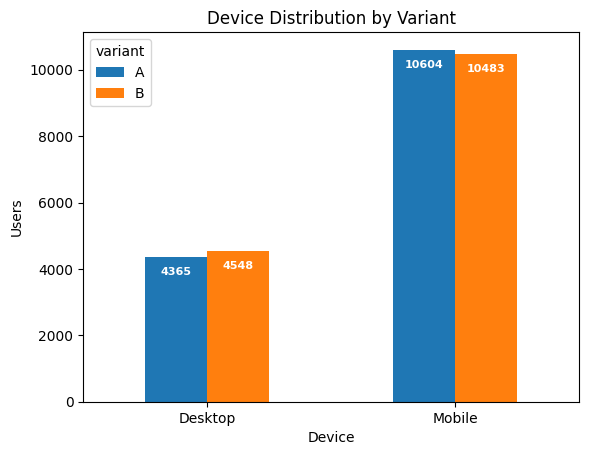

In [22]:
# Reshape data for plotting
pivot_device_dist = df_device_dist.pivot(index="device", columns="variant", values="users")

# Rename index labels
pivot_device_dist.index = ["Desktop", "Mobile"]

# Plot distribution
ax = pivot_device_dist.plot(kind="bar")

# Add labels inside bars near the top
for container in ax.containers:
    
    for bar in container:
        
        height = bar.get_height()
        
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height - 300,   
            f"{int(height)}",
            ha='center',
            va='top',
            color='white',
            fontweight='bold',
            fontsize=8
        )

plt.xlabel("Device")
plt.ylabel("Users")
plt.title("Device Distribution by Variant")

# Make labels horizontal
plt.xticks(rotation=0)

plt.show()

Device composition appears highly similar across both experimental variants, indicating that the treatment groups remain balanced across a key user segment.

This reduces the likelihood that observed conversion differences are driven by device-level allocation bias.

### ***Sample Ratio Mismatch (SRM) Check***
Sample Ratio Mismatch (SRM) occurs when the observed allocation of users deviates significantly from the expected experimental split.

If SRM is present, the experiment may suffer from:
* allocation bias,
* tracking inconsistencies,
* or randomization failures.

As a result, the validity of the experiment can become compromised.

#### *SRM Test*

In [23]:
from scipy.stats import chisquare

# Observed allocation
observed = [
    users[users["variant"] == "A"].shape[0],
    users[users["variant"] == "B"].shape[0]
]

# Expected 50/50 split
total = sum(observed)
expected = [total / 2, total / 2]

# Chi-square SRM test
chi_stat, p_val = chisquare(observed, expected)

print("SRM p-value:", p_val)

SRM p-value: 0.720375368303551


The SRM test does not detect evidence of deviation from the expected allocation ratio ($ p > 0.05 $).

This suggests that user assignment is consistent with the intended randomization process and that no meaningful sample ratio mismatch is present.

### ***Conclusion***

The validation checks indicate that the experiment setup is reliable and internally consistent:

* User allocation between variants is balanced
* No meaningful imbalance is observed across device segments
* The SRM test does not indicate allocation irregularities
* No major evidence of randomization failure is detected

Overall, these validation checks support the credibility of the experimental results and reduce the likelihood that observed treatment effects are driven by allocation bias or confounding factors.

## **STATISTICAL TESTING**
---

### ***Hypothesis***
We use a **one-sided hypothesis test** to evaluate whether Variant B improves conversion performance relative to Variant A.<br/>
* **H₀:** Conversion rate of B ≤ Conversion rate of A
* **H₁:** Conversion rate of B > Conversion rate of A

### ***Test Selection***
A **two-proportion z-test** is appropriate because:
* The outcome variable is binary (converted vs not converted)
* The experiment compares conversion rates between two independent groups
* The sample size is sufficiently large for the large-sample normal approximation to hold

### ***Assumption Validation***
The two-proportion z-test relies on the large-sample normal approximation, which requires sufficiently large counts of both successes and failures in each group.


In [25]:
# Calculate conversions and total users per variant
success = users.groupby("variant")["converted"].sum()
nobs = users.groupby("variant")["converted"].count()

# Check success/failure condition
(success > 10) & ((nobs - success) > 10)

variant
A    True
B    True
Name: converted, dtype: bool

Both variants satisfy the success/failure condition, confirming that the assumptions required for the z-test are met.

### ***Run Z-Test***

In [26]:
from statsmodels.stats.proportion import proportions_ztest

# Perform one-sided z-test (B > A)
z_stat, p_value = proportions_ztest(
    [success["B"], success["A"]],
    [nobs["B"], nobs["A"]],
    alternative='larger'
)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 8.12599058429596
P-value: 2.2186173992507971e-16


The p-value is substantially below the conventional significance threshold of 0.05 ($ p<0.5 $), leading to rejection of the null hypothesis. 

The results provide strong statistical evidence that **Variant B achieves a higher conversion rate than Variant A**.

### ***Effect Size***
Statistical significance alone does not indicate whether the observed improvement is meaningful in practice. Effect size metrics help quantify the magnitude of the treatment impact.

#### *Absolute Uplift*
Absolute uplift measures the direct difference in conversion rate between Variant B and Variant A.

$$
\text{Absolute Uplift} = p_B - p_A
$$

Where:
- $p_A$ = conversion rate of Variant A  
- $p_B$ = conversion rate of Variant B

In [27]:
# Compute conversion rates
conv_A = success["A"] / nobs["A"]
conv_B = success["B"] / nobs["B"]

# Absolute uplift
absolute_uplift = conv_B - conv_A

print("Absolute uplift:", absolute_uplift)

Absolute uplift: 0.030824789433878425


Variant B improves conversion by approximately **3.1 percentage points** compared to Variant A.

#### *Relative Uplift*
Relative uplift measures the percentage improvement relative to the baseline conversion rate.

$$
\text{Relative Uplift} = \frac{p_B - p_A}{p_A}
$$

In [28]:
# Relative uplift
relative_uplift = absolute_uplift / conv_A

print("Relative uplift:", relative_uplift)

Relative uplift: 0.2864160602332254


Variant B increases conversion by approximately **29%** relative to the baseline conversion rate.

Overall, the observed effect is both **statistically significant** and **practically meaningful**, indicating that Variant B delivers a substantial improvement in conversion performance.

### ***Confidence Intervals***
Confidence intervals provide a range of plausible values for the true conversion rates and help quantify the uncertainty associated with the observed estimates.

All confidence intervals below are reported at the **95% confidence level**. Although the hypothesis test is one-sided, two-sided 95% confidence intervals are reported because they provide a standard and symmetric measure of estimation uncertainty.

#### *Confidence Intervals for Conversion Rates*

In [29]:
import statsmodels.api as sm

# Compute 95% confidence intervals
ci_A = sm.stats.proportion_confint(success["A"], nobs["A"], method="wilson")
ci_B = sm.stats.proportion_confint(success["B"], nobs["B"], method="wilson")

print("CI A:", ci_A)
print("CI B:", ci_B)

CI A: (0.10275818342892531, 0.11268799408471622)
CI B: (0.1330182724080476, 0.14406090200364285)


The confidence intervals indicate that Variant B consistently achieves higher conversion rates than Variant A, reinforcing the statistical evidence observed in the hypothesis test.

#### *Confidence Interval for Uplift*
A confidence interval for the treatment effect provides a direct estimate of the uncertainty surrounding the observed uplift.

In [30]:
from statsmodels.stats.proportion import confint_proportions_2indep

# 95% confidence interval for uplift
uplift_ci = confint_proportions_2indep(
    success["B"], nobs["B"],
    success["A"], nobs["A"],
    method="score"
)

print("95% CI for uplift:", uplift_ci)

95% CI for uplift: (0.023410305424895108, 0.038241680189080564)


Because the confidence interval excludes zero, the estimated uplift remains consistently positive at the 95% confidence level.

This provides additional evidence that the treatment effect is unlikely to be driven by random variation alone.

#### *Visualization of Conversion Rates with Confidence Intervals*

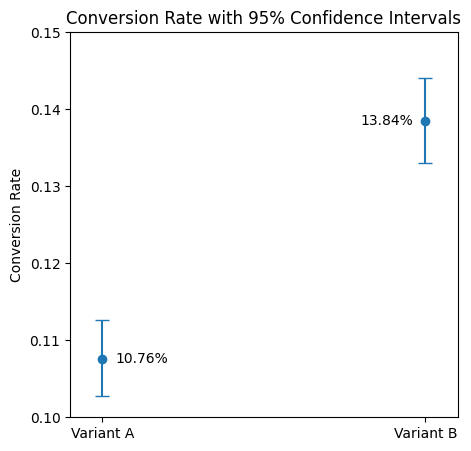

In [31]:
# Labels and means
labels = ["Variant A", "Variant B"]
means = [conv_A, conv_B]

# Lower and upper CI bounds
lower = [ci_A[0], ci_B[0]]
upper = [ci_A[1], ci_B[1]]

# Error bar distances
errors = [
    [means[i] - lower[i] for i in range(2)],
    [upper[i] - means[i] for i in range(2)]
]

# Numeric x positions
x = [0, 1]

plt.figure(figsize=(5, 5))

plt.errorbar(x, means, yerr=errors, fmt='o', capsize=5)
plt.xticks(x, labels)

# Add conversion rate labels
offsets = {0: 0.04,  1: -0.2}

for i, mean in enumerate(means):

    plt.text(x[i] + offsets[i], mean, f"{mean:.2%}", va='center')

plt.ylabel("Conversion Rate")
plt.title("Conversion Rate with 95% Confidence Intervals")
plt.xlim(-0.1, 1.1)
plt.ylim(0.10, 0.15)

plt.show()

* Variant B shows a clearly higher conversion rate than Variant A.
* The confidence intervals are relatively narrow, indicating stable conversion estimates and low sampling variability.
* The observed uplift remains consistently positive, supporting the reliability of the treatment effect.
* Together, the hypothesis test, effect size metrics, and confidence intervals provide strong evidence that Variant B improves conversion performance.

### ***CONCLUSION***

Variant B delivers a statistically significant and practically meaningful improvement in conversion performance, with an approximate **3.1 percentage point absolute uplift** corresponding to a **~29% relative increase** over Variant A.

The hypothesis test provides strong evidence against the null hypothesis, while the confidence intervals indicate that the observed improvement is both stable and reliable. Given proper experimental randomization and valid test conditions, the results are consistent with a causal impact of the treatment.

From a business perspective, even a modest increase in conversion rate can translate into substantial gains in user acquisition, engagement, or revenue at scale. Overall, the analysis strongly supports adopting Variant B as the preferred design.

## **ADVANCED ANALYSIS**
---

To further evaluate the robustness of the experiment, we assess whether the treatment effect remains consistent across user segments and evaluate whether the observed uplift persists after controlling for additional user characteristics.

### ***Segmentation Analysis — Conversion Rate by Device***
To evaluate whether experiment performance varies across device types, we compare conversion rates separately for desktop and mobile users.

In [32]:
# Compute conversion rate by device and variant
df_device = users.groupby(["device", "variant"])["converted"].mean().reset_index()

# Reshape for comparison
device_pivot = df_device.pivot(index="device", columns="variant", values="converted")
device_pivot

variant,A,B
device,,
desktop,0.117297,0.153474
mobile,0.103640,0.131928


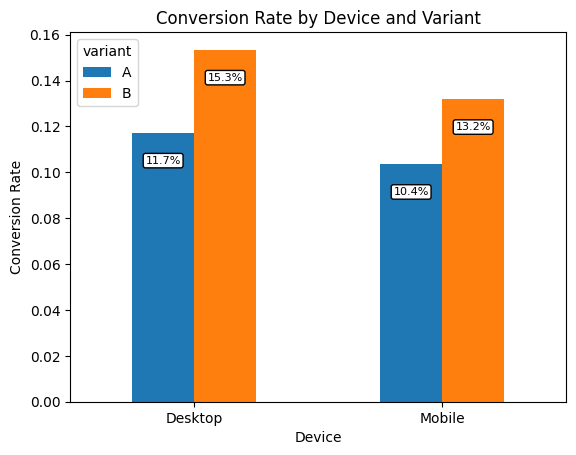

In [34]:
# Rename index labels
device_pivot.index = ["Desktop", "Mobile"]

# Visualize conversion rates across devices
ax = device_pivot.plot(kind="bar")

# Add values inside bars near the top
for container in ax.containers:
    
    for bar in container:
        
        height = bar.get_height()
        
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height - 0.01,
            f"{height:.1%}",
            ha='center',
            va='top',
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="black"
            )
        )

plt.xlabel("Device")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Device and Variant")
plt.xticks(rotation=0)

plt.show()

* Variant B improves conversion across both desktop and mobile users.
* Desktop users appear to exhibit somewhat higher baseline conversion rates than mobile users.
* The treatment effect remains positive across both device segments, indicating that Variant B performs reliably across device types.
* Mobile users show lower overall conversion rates, potentially reflecting differences in user experience or interaction constraints on smaller devices.

### ***Interaction Effects (Logistic Regression)***
To formally evaluate whether the treatment effect differs across devices, we fit a logistic regression model with an interaction term between variant and device type.

In [35]:
# Test whether treatment effect varies by device
import statsmodels.formula.api as smf

model = smf.logit("converted ~ variant * device", data=users).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.371587
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29996
Method:                           MLE   Df Model:                            3
Date:                Sat, 09 May 2026   Pseudo R-squ.:                0.003765
Time:                        10:10:00   Log-Likelihood:                -11148.
converged:                       True   LL-Null:                       -11190.
Covariance Type:            nonrobust   LLR p-value:                 3.743e-18
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.0183      0.047    -42.907      0.

**Model Interpretation:**

The interaction term between **variant** and **device** (`variant × device`) is not statistically significant ($ p > 0.05 $).

No statistically significant evidence suggests that the treatment effect differs across device types.

This indicates that the uplift associated with Variant B remains relatively stable across major user segments.

### ***Extended Model (Multiple Drivers of Conversion)***
To evaluate whether the treatment effect remains robust after accounting for additional user characteristics, we extend the logistic regression model to include device type and customer history.

In [36]:
# Include additional drivers of conversion
model_full = smf.logit("converted ~ variant + device + previous_customer", data=users).fit()

print(model_full.summary())

Optimization terminated successfully.
         Current function value: 0.371277
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29996
Method:                           MLE   Df Model:                            3
Date:                Sat, 09 May 2026   Pseudo R-squ.:                0.004594
Time:                        10:10:11   Log-Likelihood:                -11138.
converged:                       True   LL-Null:                       -11190.
Covariance Type:            nonrobust   LLR p-value:                 3.862e-22
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.0439      0.038    -53.720      0.000      -2.118      -1.969
variant[

**Model Interpretation:**

The logistic regression coefficients are expressed in **log-odds units**. <br/>
To improve interpretability, the coefficients are converted to **odds ratios** below.

In [37]:
# Convert coefficients to odds ratios
odds_ratios = np.exp(model_full.params)
print(odds_ratios)

Intercept            0.129524
variant[T.B]         1.329254
device[T.mobile]     0.852463
previous_customer    1.201615
dtype: float64


* **Variant B:** Users exposed to Variant B have approximately **1.31× higher odds of conversion** compared to Variant A.
* **Mobile Users:** Mobile users have approximately **0.85× the odds of conversion** relative to desktop users.
* **Previous Customers:** Returning customers have approximately **1.20× higher odds of conversion** than new users.

The treatment effect remains positive and statistically significant even after controlling for device type and customer history, reinforcing the robustness of the experimental findings.

Mobile users continue to exhibit lower baseline conversion rates, while returning customers demonstrate stronger purchase intent and higher likelihood of completing the onboarding journey.

**Model Preformance Note:**<br/>
Although the pseudo $R^2$ value is relatively small, this is common in user-level conversion models where individual outcomes are inherently noisy and influenced by many unobserved behavioral factors.

### ***Conclusion***
* Variant B improves conversion consistently across user segments, with no evidence of heterogeneous treatment effects.
* The interaction analysis indicates that the treatment effect does not significantly depend on device type.
* Device type and customer history influence baseline conversion rates, but do not alter the effectiveness of the treatment.
* The treatment effect remains robust after controlling for multiple user characteristics, reinforcing the validity of the experimental results.
* No evidence of Simpson’s paradox is observed, as the direction of the treatment effect remains consistent across all analyzed segments.

## **BUSINESS IMPACT & FINAL RECOMMENDATION**
---

### ***Business Impact***
To evaluate practical significance, the observed treatment uplift is translated into estimated business outcomes under a realistic operating scenario.

#### *Key Assumptions*
* Monthly users: **1,000,000**
* Conversion Rate (Variant A): **10.8%**
* Conversion Rate (Variant B): **13.8%**
* Average revenue per conversion: **₹500**

#### *Incremental Impact*

In [38]:
# Define key business assumptions
monthly_users = 1_000_000              # Total users per month
conv_A = 0.108                        # Baseline conversion rate (Variant A)
conv_B = 0.138                        # Improved conversion rate (Variant B)
revenue_per_conversion = 500          # Average revenue per conversion (₹)

# Calculate incremental impact of Variant B over A
incremental_conversions = monthly_users * (conv_B - conv_A)             # Additional conversions per month
incremental_revenue = incremental_conversions * revenue_per_conversion  # Additional monthly revenue

# Output results
incremental_conversions, incremental_revenue

(30000.000000000015, 15000000.000000007)

#### *Estimated Business Impact*
* **Absolute uplift**: +3.1 percentage points
* **Incremental conversions**: ~30,000 additional conversions per month
* **Incremental revenue**: ~₹15,000,000 (₹1.5 crore) per month

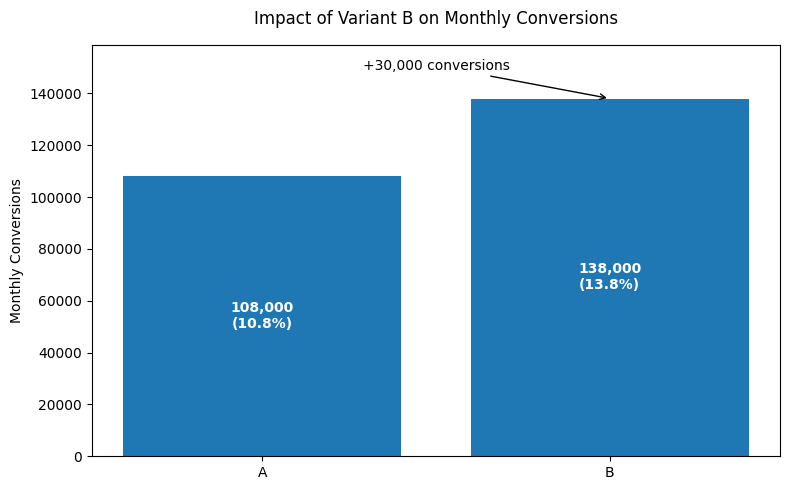

In [39]:
# Business Impact Visualization

variants = ["A", "B"]
conversion_rates = [conv_A, conv_B]
conversions = [
    conv_A * monthly_users,
    conv_B * monthly_users
]

plt.figure(figsize=(8, 5))
bars = plt.bar(variants, conversions)

for i, bar in enumerate(bars):
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height * 0.5,   
        f"{int(height):,}\n({conversion_rates[i]:.1%})",
        ha='center',
        va='center',
        color='white',     
        fontsize=10,
        fontweight='bold'
    )

# Uplift annotation
uplift = conversions[1] - conversions[0]
plt.annotate(
    f"+{int(uplift):,} conversions",
    xy=(1, conversions[1]),
    xytext=(0.5, conversions[1] * 1.08),
    arrowprops=dict(arrowstyle="->"),
    ha='center'
)

plt.ylabel("Monthly Conversions")
plt.title("Impact of Variant B on Monthly Conversions", pad=15)

plt.ylim(0, max(conversions) * 1.15)

plt.tight_layout()
plt.show()

The redesigned onboarding experience (Variant B) produces a statistically significant and practically meaningful improvement in conversion performance, translating into substantial incremental revenue at scale.

Even relatively modest percentage improvements can generate large absolute gains in high-traffic systems. In this scenario, a ~3 percentage point uplift corresponds to approximately **30,000 additional monthly conversions** and **\~₹1.5 crore in incremental monthly revenue**.

Actual business impact would depend on factors such as traffic stability, conversion quality, customer retention, and realized customer value over time.

### ***Decision Framework***

#### **1. Statistical Validity**
* Statistically significant uplift in conversion performance ($p≪0.05$)
* Confidence intervals indicate a consistently positive treatment effect
* No evidence of sample ratio mismatch (SRM)
* Validation checks support reliable experimental randomization

#### **2. Consistency Across Segments**
* Positive uplift observed across both desktop and mobile users
* No statistically significant interaction effects detected
* Treatment effect remains stable across major user segments

#### **3. Funnel Insights**
* Funnel analysis identifies **form → submit** as the primary conversion bottleneck
* Variant B achieves stronger completion performance at the final submission stage
* The treatment effect appears concentrated near the end of the onboarding journey, suggesting improved completion efficiency during the largest conversion bottleneck in the funnel

### ***Final Recommendation***
Proceed with a full rollout of **Variant B** while continuing post-deployment monitoring.
The redesigned onboarding experience delivers:
- statistically robust conversion improvement,
- meaningful projected business impact,
- and consistent performance across major user segments.
The experimental evidence strongly supports adopting Variant B as the preferred onboarding experience.

### ***Risk & Monitoring Plan***
To ensure sustained performance after deployment:
* Monitor mobile conversion rates as a guardrail metric
* Track funnel abandonment near the form submission stage
* Validate that treatment performance remains stable over time
* Monitor for potential novelty effects or performance regression after rollout

### ***Next Steps***
* Roll out Variant B to production traffic
* Prioritize further optimization of the mobile onboarding experience
* Run follow-up experiments focused on form simplification, submission flow optimization, and onboarding completion efficiency
* Continue iterative experimentation to compound conversion improvements over time

## **EXECUTIVE SUMMARY**

The A/B experiment demonstrates that Variant B delivers a statistically significant and practically meaningful improvement in conversion performance, increasing conversion rates by approximately **3 percentage points** (~29% relative uplift).

The treatment effect remains consistent across major user segments and is primarily concentrated near the final submission stage of the onboarding funnel, indicating improved completion efficiency during a key bottleneck in the user journey.

At scale (1 million monthly users), the observed uplift corresponds to an estimated **~30,000 additional monthly conversions** and **~₹1.5 crore in incremental monthly revenue**.

Given the robustness of the statistical results, the absence of allocation bias, and the consistency of the treatment effect across segments, the analysis supports a full rollout of Variant B alongside continued post-deployment monitoring and iterative optimization.